In [10]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
import os

In [11]:
os.chdir(r"C:\Users\JxLee\Documents\GitHub\FYP2021")
os.path.exists(r"b03-025")

True

img.shape: (76, 163)


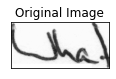

In [12]:
#INPUT IMAGE
v = r'b03-025\b03-025-03-05.png'
img = cv.imread(v,0)
plt.subplot(2,3,1),plt.imshow(img,'gray',vmin=0,vmax=255)
plt.title("Original Image")
plt.xticks([]),plt.yticks([])
print('img.shape:',img.shape)
plt.show()

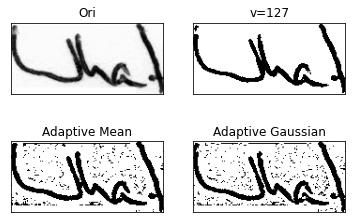

In [13]:
#binarization

ret,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
th2 = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_MEAN_C,\
            cv.THRESH_BINARY,11,2)
th3 = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv.THRESH_BINARY,11,2)
titles = ['Ori','v=127','Adaptive Mean','Adaptive Gaussian']
images = [img,th1,th2,th3]

for i in range(4):
    plt.subplot(2,2,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])

(76, 163)

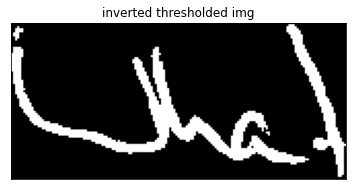

In [14]:
thImg = images[1]

#empty skenleton
size = np.size(thImg)
skel = np.zeros(thImg.shape, np.uint8)

thImg[thImg == 0] = 254
thImg[thImg == 255] = 0
thImg[thImg == 254] = 255

plt.imshow(thImg,'gray')
plt.title('inverted thresholded img')
plt.xticks([]),plt.yticks([])
plt.plot()
thImg.shape



In [15]:
skeleton = skeletonize(thImg)

plt.imshow(skeleton,'gray')
plt.title('skel img')
plt.xticks([]),plt.yticks([])
plt.plot()

ValueError: Image contains values other than 0 and 1

element: [[0 1 0]
 [1 1 1]
 [0 1 0]]


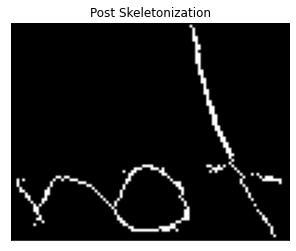

In [ ]:
element = cv.getStructuringElement(cv.MORPH_CROSS,(3,3))
done = False

while(not done):
    eroded = cv.erode(thImg,element)
    temp = cv.dilate(eroded,element)
    temp = cv.subtract(thImg,temp)
    skel = cv.bitwise_or(skel,temp)
    thImg = eroded.copy()
 
    zeros = size - cv.countNonZero(thImg)
    if zeros==size:
        done = True

plt.imshow(skel,'gray')
plt.title('Post Skeletonization')
plt.xticks([]),plt.yticks([])
plt.plot()
print('element:',element)



ele2:
 [[0 1 0]
 [1 1 1]
 [0 1 0]] 
ele3
: [[1 1 1]
 [1 1 1]
 [1 1 1]]


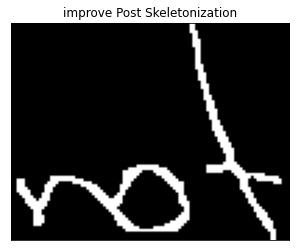

In [ ]:
#improve and connect the gap betweem skeletonized image
element2 = cv.getStructuringElement(cv.MORPH_DILATE,(3,3))
element3 = cv.getStructuringElement(cv.MORPH_ERODE,(3,3))
skel2 = skel

for i in range(2):
    skel2 = cv.dilate(skel2,element3)
    skel2 = cv.erode(skel2,element2)

# skel2 = cv.dilate(skel2,element)
# skel2 = cv.erode(skel2,element3)


plt.imshow(skel2,'gray')
plt.title('improve Post Skeletonization')
plt.xticks([]),plt.yticks([])
plt.plot()
print('ele2:\n',element2,'\nele3\n:',element3)



element: [[0 1 0]
 [1 1 1]
 [0 1 0]]


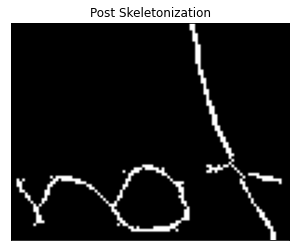

In [ ]:
element = cv.getStructuringElement(cv.MORPH_CROSS,(3,3))
done = False
thImg = skel2

while(not done):
    eroded = cv.erode(thImg,element)
    temp = cv.dilate(eroded,element)
    temp = cv.subtract(thImg,temp)
    skel = cv.bitwise_or(skel,temp)
    thImg = eroded.copy()
 
    zeros = size - cv.countNonZero(thImg)
    if zeros==size:
        done = True

plt.imshow(skel,'gray')
plt.title('Post Skeletonization')
plt.xticks([]),plt.yticks([])
plt.plot()
print('element:',element)

[]

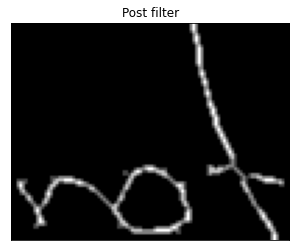

In [ ]:
blur = cv.blur(skel,(2,2))

plt.imshow(blur,'gray')
plt.title('Post filter')
plt.xticks([]),plt.yticks([])
plt.plot()